# WINDMI Substorm Onset Identification — Case Study Notebook

This notebook runs the WINDMI magnetosphere–ionosphere model for a five-day case study interval (January 9–13, 2000) and reproduces the figures in the paper. 

1. ACE solar-wind measurements are propagated to the magnetopause. Compared with OMNI data (Figure S1 in paper)
2. Input coupling voltage is calculated that drives the model.
3. Run WINDMI in three configurations.
4. Figure 1 : WINDMI Inputs and outputs.
5. Figure 2 : Geotail current from run 1 and run 2, with threshold current and derived theta values compared with SML index and onsets from existing substorm lists.

**Dependencies:** `numpy`, `pandas`, `scipy`, `matplotlib`, `tqdm`


# Imports

In [2]:
import os
import datetime as dt
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp
from tqdm import tqdm
from numpy import sin, pi
# %matplotlib widget

## Simulation interval

Start and stop times for the case-study period. A ±2-hour buffer is added when loading data to avoid edge effects after the propagation time-shift.


In [ ]:
start = dt.datetime(2000,1,9); 
stop = dt.datetime(2000,1,13);

## Load ACE solar-wind data

The pre-processed ACE Level-2 file for 2000 is read and trimmed to the simulation window (±2-hour buffer). Expected columns: `Bx`, `By`, `Bz` (IMF, nT), `Vx`, `Vy`, `Vz` (km/s), `Np` (proton density, cm⁻³).

> Update `ACE_dir` to your local data directory before running.


In [ ]:
ACE_dir = "C:/Users/soumy/OneDrive/Documents/src/2024-04 WINDMI Identification/data1/"
os.chdir(ACE_dir)
data = pd.read_csv("ACE_" + str(start.year) + ".csv")
data.index = pd.to_datetime(data['Time'])
data.drop(columns=["Time"], inplace=True)
data = data.iloc[(data.index >= start-dt.timedelta(hours=2)) & (data.index <= stop + dt.timedelta(hours=2))]

## Load SuperMAG SML index

The SuperMAG Lower (SML) index is loaded for use as an observational reference in the figures. It is not used as a model driver.


In [ ]:
SuperMag_filename = os.path.join("C:/Users/soumy/OneDrive/Documents/src/ACE_Data",
                                  f"SuperMag_{start.year}.csv")
SuperMag = pd.read_csv(SuperMag_filename)
SuperMag.index = pd.DatetimeIndex(SuperMag.Date_UTC).tz_localize(None)
SuperMag.drop(columns=["Date_UTC"], inplace=True)

## Calculate the time delay

ACE is located ~250 R_E upstream. Each measurement is time-shifted to the dayside magnetopause using the Shue et al. (1998) empirical magnetopause standoff distance *R_subsolar*, which depends on the solar-wind dynamic pressure *D_p* and IMF *B_z*.

The propagation delay at each time step is:

    Δt = −( (250 − R_subsolar) × R_E ) / Vx

A scalar version (`t_delay`) based on time-averaged conditions is also retained for reference.


In [ ]:
# time_substorm = np.arange(200, 600, 1)  # time indices for substorm interval
Dp = 1.67e-6 * data['Np'] * data['Vx']**2  # dynamic pressure in nPa
R_subsolar = (10.22 + 1.29*np.tanh(0.184*(data['Bz'] + 8.14))) * (Dp**(-1/6.6))  # subsolar magnetopause standoff distance in RE  
t_delay = -((250.0 - np.nanmean(R_subsolar)) * 6380.0) / np.nanmean(data['Vx'])  # for constant delay
t_delay_windmi = -((250.0 - R_subsolar) * 6380.0) / data['Vx'].rolling(window=20, min_periods=1, center=True).mean()  # time delay array for WINDMI model

## Shift the ACE Data

`apply_windmi_time_shift` shifts the ACE timestamps by the local propagation delay and resamples onto a uniform 1-minute grid via linear interpolation. Duplicate timestamps and NaT indices produced by the shift are removed beforehand. The output is trimmed to the exact simulation window.


In [ ]:
def apply_windmi_time_shift(data, t_delay_windmi):
    data_shifted = data.copy()
    # Shift time index by time-varying delay (seconds)
    data_shifted.index = data_shifted.index + pd.to_timedelta(
        t_delay_windmi, unit="s")
    data_shifted = data_shifted.sort_index()
    data_shifted = data_shifted[~data_shifted.index.isna()]
    #remove duplicate indices after shifting
    data_shifted = data_shifted[~data_shifted.index.duplicated(keep='first')]

    t_start = data_shifted.index.min().floor("min")
    t_end   = data_shifted.index.max().ceil("min")
    x0 = np.array((data_shifted.index - t_start)/dt.timedelta(seconds=1))  # original time index in seconds
    x1_time = pd.date_range(t_start, t_end, freq="1min")      # <- whole minutes
    x1 = np.array((x1_time - t_start)/dt.timedelta(seconds=1))  # resampled time index in seconds 
    df = pd.DataFrame(index=x1_time)
    for col in data_shifted.columns:
        y0 = data_shifted[col].values
        y1 = interp1d(x0, y0, kind="linear", bounds_error=False, fill_value=np.nan)(x1)
        df[col] = y1
    #remove rows with NaN values
    
    df = df.dropna().reset_index()
    df = df.set_index('index')
    return df

data = apply_windmi_time_shift(data, t_delay_windmi)
data = data.loc[start:stop];

## Load OMNI 1-min data

OMNI propagated solar-wind data are loaded for comparison with the time-shifted ACE input. Fill values (9999.99 for *B_z*, 99999.9 for *V_x*) are removed. OMNI is not used as a WINDMI driver.


In [ ]:
omni = pd.read_csv("C:/Users/soumy/OneDrive/Documents/Temp/omni_min_def_trbjdCQglg.lst", header=None, delim_whitespace=True,
                   names=['Year', 'DOY', 'Hour', 'Minute', 'Bz', 'Vx'])
omni = omni[(omni.Bz != 9999.99)]
omni = omni[(omni.Vx != 99999.9)]
omni.index = pd.DatetimeIndex(pd.to_datetime(omni[['Year', 'DOY', 'Hour', 'Minute']].apply(lambda x: f"{x['Year']}-{x['DOY']} {x['Hour']}:{x['Minute']}", axis=1), format="%Y-%j %H:%M"))
omni.drop(columns=['Year', 'DOY', 'Hour', 'Minute'], inplace=True)
omni = omni.loc[start:stop]

C:\Users\soumy\AppData\Local\Temp\ipykernel_7824\1129322589.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  omni = pd.read_csv("C:/Users/soumy/OneDrive/Documents/Temp/omni_min_def_trbjdCQglg.lst", header=None, delim_whitespace=True,


### ACE vs. OMNI comparison (Figure S1)

Agreement between the two series confirms the propagation delay is physically reasonable.


In [ ]:
plt.subplots(2,1,figsize=(10, 6),sharex=True)

plt.subplot(2,1,1)
plt.plot(data.index, -Vx, label='WINDMI input')
plt.plot(omni.index, -omni['Vx'], label='OMNI 1-min')
plt.ylabel('-Vx (km/s)',fontsize=12)
plt.legend(fontsize=12)
plt.grid()
plt.yticks(fontsize=12);
plt.text(-0.08, 0.95, 'a.', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top')

plt.subplot(2,1,2)
plt.plot(data.index, Bz, label='WINDMI input')
plt.plot(omni.index, omni['Bz'], label='OMNI 1-min')
plt.ylabel('Bz (nT)',fontsize=12)
plt.legend(fontsize=12)
plt.grid()
plt.text(-0.08, 0.95, 'b.', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top')

# set xtick fontsize
plt.xticks(fontsize=12);
plt.yticks(fontsize=12);

plt.tight_layout()
plt.savefig("C:/Users/soumy/OneDrive/Documents/Plots/input_comparison.jpg", dpi=300)

## Calculate the input voltage

Three solar-wind coupling voltage formulations are computed. The **VBs** formula (`Vsw0`) is used as the WINDMI driver and stored as `data['vBs']`:

    VBs = 4000 + Ly |Vx Bz_input|

where *B_z_input* = |*B_z*| when *B_z* < 0 and zero otherwise, and *L_y* = 10 R_E.

The Siscoe–Hill potential (`Vsw1`) and the scaled Newell reconnection rate (`Vsw2`) are computed for reference but not used in the paper runs.


In [ ]:
Bx = data['Bx']; By = data['By']; Bz = data['Bz']; # IMF components in nT
Vx = data['Vx']; Vy = data['Vy']; Vz = data['Vz']; # Solar wind velocity components in km/s
Np = data['Np']; # Solar wind proton density in cm^-3 

In [ ]:
# Input voltages
R_E = 6380.0e3  # Earth radius in m
Ly = 10.0 * R_E # effective width of magnetosphere in solar wind dynamo

# VBs formula
Bz_input = 0.5 * (np.abs(Bz) - Bz)  # if Bz < 0, Bz_input = |Bz| else Bz_input = 0
Vsw0 = 4000.0 + (1.0e-6 * Ly * np.abs(Vx * Bz_input))  # Solar wind coupling function

# Siscoe-Hill formula
m_p = 1.67e-27  # mass of proton in kg
B_abs = np.abs(Bx**2 + By**2 + Bz**2) # magnitude of IMF in nT
theta = np.arccos(Bz/B_abs)  # IMF clock angle in radians
v_sw = np.sqrt(Vx**2 + Vy**2 + Vz**2)  # solar wind speed in km/s
Esw = (v_sw*1e3) * (np.sqrt(By**2 + Bz**2)*1e-9) * np.sin(theta/2.0);
Psw = m_p * (Np * 1.0e6) * ((v_sw*1.0e3)**2)  # solar wind dynamic pressure in Pa
Phi_M = 30.0 + (57.6 * (Esw*1.0e3) * ((1.0e9 * Psw) ** (-1.0 / 6.0))) # magnetospheric potential in kV
Vsw1 = 1e3*Phi_M;

C0 = 0.77;
F107 = 172.42; # its supposed to be monthly mean
SigmaP = C0 * np.sqrt(F107);
Phi_S = 1600.0 * ((Psw*1.0e9)**(1/3))/SigmaP # saturation voltage
Phi_H = (Phi_M * Phi_S) / (Phi_M + Phi_S)  # Hill potential

# Newell et al. 2007
DPhi_mp = (np.abs(Vx)**(4/3)) * (B_abs**(2/3)) * (np.sin(theta / 2.0)**(8/3))  # dayside reconnection rate in kV
Vsw2 = 4000.0 + (np.mean(Vsw0)/np.mean(DPhi_mp))*DPhi_mp;  # scaled Newell coupling function

data['vBs'] = Vsw0;  # choose VBs as input voltage for WINDMI model

# Substorm lists

Five published substorm onset lists are loaded (Forsyth et al. 2015, Frey et al. 2004, Liou 2010, Newell & Gjerloev 2011, Ohtani & Gjerloev 2020), along with the merged reference catalog from Adhya et al. (2025). In the merged catalog, onsets within 15 minutes of each other are consolidated into a single event; only isolated onsets with no prior onset within two hours are retained. The `score` column records how many lists identified each merged event (1–5).


In [ ]:
# Get the substorm lists
keywords = ['Forsyth', 'Frey','Liou','Newell','Ohtani']

for key in keywords:
    filename = ACE_dir +  f"../Data0/Substorms_{key}_1970_to_2022.csv";
    df = pd.read_csv(filename)
    df.index = pd.to_datetime(df['Date_UTC'])
    # globals()[f"{key}"] = df.loc[start:stop]
    globals()[f"{key}"] = df;

In [ ]:
substorms_all = pd.read_csv(ACE_dir + "../Data1/Substorms_all_09-30.csv")
substorms_all.index = pd.to_datetime(substorms_all['Date_UTC'])
substorms_all = substorms_all.loc[start:stop]
substorms_all['score'] = substorms_all['Forsyth'] + substorms_all['Frey'] + substorms_all['Liou'] + substorms_all['Newell'] + substorms_all['Ohtani'];

# WINDMI code

## Model parameters

Default constants for the WINDMI circuit model (Horton & Doxas 1996, 1998; Spencer et al. 2006). The state vector is:

    X(t) = [I, V, I₁, V_I, p, K_k, I₂, W_rc]

| Symbol | Description | Unit |
|---|---|---|
| *I* | Geotail cross-tail current | A |
| *V* | Plasma-sheet voltage | V |
| *I₁* | Region-1 Birkeland current | A |
| *V_I* | Ionospheric voltage | V |
| *p* | Plasma-sheet pressure | Pa |
| *K_k* | Parallel kinetic energy flux | W |
| *I₂* | Ring-current current | A |
| *W_rc* | Ring-current energy | J |

Parameters L, C, Σ, and *I_c* are overridden at runtime for Cases 2 and 3.


In [ ]:
# create a dictionary of inputs
p = {
    # --- Inductances ---
    "L": 90.0,                    # Inductance of the lobe cavity
    "L1": 20.0,                    # Region-1 current inductance
    "L2": 8.0,                     # Ring current inductance

    "L_y": 3.2e7,                  # Cross-tail length scale [m]

    # --- Capacitances ---
    "C": 5.0e4,                   # Plasma sheet capacitance
    "C1": 8.0e2,                   # capacitance of R1 current loop

    # --- Resistances ---
    "R_prc": 0.1,                  # Partial ring current resistance
    "R_A2": 0.3,                   # Region-2 Alfven resistance

    "M": 0.1,                      # mutual inductance between I and I1 (in the paper its 1.0?)

    # --- Currents ---
    "DeltaI": 1.25e5,              # Delta I in theta function

    # --- Conductances ---
    "Sigma": 8.0,                  # Plasma sheet conductance
    "SigmaI": 3.0,                 # pedersen conductance of westward electrojet current

    # --- Magnetic / EM constants ---
    "u0": 4.2e-9,                 # heat flux limit paramter
    "Aeff": 8.14e13,              # Effective cross-sectional area [m^2]
    "Btr": 5.0e-9,                # Trigger magnetic field threshold [T]

    # --- Energetics ---
    "Omega_cps": 2.6e24,           # Plasma sheet volume
    "Alpha": 8.0e11,               # Energy coupling coefficient

    # --- Time constants ---
    "tauE": 30.0 * 60.0,          # Energy decay timescale [s]
    "tauk": 10.0 * 60.0,          # confinement time of parallel flow [s]
    "taurc": 12.0 * 3600.0,       # Ring current decay time [s]
            
    "beta_sw": 0.7,               # Coupling factor for SW across magnetopause

    "Ic_trig": 2.0e7              # Threshold current for substorm onset in A    
}

## Onset trigger and ODE solver

The onset trigger is a smooth approximation to the Heaviside step:

    Θ(I − I_c) = 0.5 × (1 + tanh((I − I_c) / ΔI))

When Θ → 1, the onset threshold has been crossed. `windmi_rhs` evaluates the eight coupled ODEs (Eqs. 9–16, Spencer & Horton 2006). `solve_windmi_rk45` wraps `scipy.integrate.solve_ivp` with a 60-second maximum step size and optional per-step overrides of L, C, Σ for Case 3.


In [ ]:
def _H_switch(I, Ic, DeltaI):
    # Eq. (17): H(I - Ic) = 0.5 * (1 + tanh((I - Ic)/DeltaI))
    return 0.5 * (1.0 + np.tanh((I - Ic) / DeltaI))

def windmi_rhs(t, p, x, Vsw):
    """
    State vector (paper): X(t) = (I, V, I1, VI, p, Kk, I2, Wrc)
    Eqs. (9)-(16) in Spencer & Horton (2006). :contentReference[oaicite:2]{index=2}
    """

    I, V, I1, VI, pres, Kk, I2, Wrc = x
    ## WINDMI constants and parameters
    L = p["L"] ;L1 = p["L1"]; L2 = p["L2"] ; L_y = p["L_y"];                  
    C = p["C"]; C1 = p["C1"];
    R_prc = p["R_prc"]; R_A2 = p["R_A2"];

    M = p["M"]; DeltaI = p["DeltaI"]; SigmaI = p["SigmaI"];
    u0 = p["u0"]; Aeff = p["Aeff"]; Btr = p["Btr"];
    
    Omega_cps = p["Omega_cps"]; Alpha = p["Alpha"];
    tauE = p["tauE"]; tauk = p["tauk"]; taurc = p["taurc"]; beta_sw = p["beta_sw"];

    # The real players 
    L = p["L"]; C = p["C"]; Sigma = p["Sigma"]; Ic_trig = p["Ic_trig"];

    # --- derived terms ---
    H = _H_switch(I, Ic_trig, DeltaI)

    # --- failsafe for non-physical negative values ---
    pres = max(pres, 0.0);
    Kk   = max(Kk,   0.0);
    Wrc  = max(Wrc,  0.0);

    Ips = Alpha * np.sqrt(max(pres, 0.0))  # Ips = a p^{1/2}

    # Unloading / injection coupling term used in Eq. (11) and Eq. (16)
    # (paper term appears as p V Aeff / (Xcps Btr Ly) in Eq. 11 and p V Aeff / (Btr Ly) in Eq. 16)
    inj_ps = (pres * V * Aeff) / (Omega_cps * Btr * L_y)
    inj_rc = (pres * V * Aeff) / (Btr * L_y)

    # --- Solve the coupled inductive pair (Eqs. 9 & 13) for dI/dt and dI1/dt ---
    # Eq (9):  L dI/dt  = bsw Vsw - V + M dI1/dt
    # Eq (13): LI dI1/dt = V - VI + M dI/dt
    # Write as:
    # [ L   -M ] [dI ] = [ bsw Vsw - V ]
    # [ -M  LI ] [dI1]   [ V - VI       ]
    A = np.array([[L, -M],
                [-M, L1]], dtype=float)
    b = np.array([beta_sw*Vsw - V,
                V - VI], dtype=float)

    detA = A[0,0]*A[1,1] - A[0,1]*A[1,0]   # = L*L1 - M^2

    # failsafe thresholds (tune if needed)
    eps_det = 1e-12
    max_cond = 1e12

    if abs(detA) < eps_det or np.linalg.cond(A) > max_cond:
        # fallback: least-squares / pseudo-inverse (won’t crash)
        dI, dI1 = np.linalg.lstsq(A, b, rcond=None)[0]
    else:
        dI, dI1 = np.linalg.solve(A, b)

    # Eq (10): C dV/dt = I - I1 - Ips - R V
    dV = (I - I1 - Ips - Sigma*V) / C

    # Eq (11): (3/2) dp/dt = R V^2 / Xcps - u0 p Kk^{1/2} H - p V Aeff/(Xcps Btr Ly) - (3p)/(2 tauE)
    # => dp/dt = (2/3)*[ ... ]
    dP = (2.0/3.0) * ( ((Sigma * V * V) / Omega_cps)
                       - (u0 * pres * np.sqrt(max(Kk, 0.0)) * H)
                       - inj_ps
                       - ((3.0 * pres)/(2.0 * tauE)) )

    # Eq (12): dKk/dt = Ips V - Kk/tauk
    dKk = Ips * V - (Kk / tauk)

    # Eq (14): CI dVI/dt = I1 - I2 - RI VI
    dVI = (I1 - I2 - (SigmaI * VI)) / C1

    # Eq (15): L2 dI2/dt = VI - (Rprc + RA2) I2
    dI2 = (VI - ((R_prc + R_A2) * I2)) / L2

    # Eq (16): dWrc/dt = Rprc I2^2 + p V Aeff/(Btr Ly) - Wrc/taurc
    dWrc = (R_prc * (I2**2)) + inj_rc - (max(Wrc, 0.0) / taurc)

    return np.array([dI, dV, dI1, dVI, dP, dKk, dI2, dWrc], dtype=float)

def solve_windmi_rk45(t_seconds,
                      p,
                      Vsw,
                      x0=None, 
                      rtol=1e-6, 
                      atol=1e-9,  
                      Ic_trig=None,
                      L = None, C = None, Sigma = None):
    
    t_seconds = np.asarray(t_seconds, dtype=float);
    Vsw = np.asarray(Vsw, dtype=float);
    # default initial condition if not provided
    if x0 is None:
        x0 = np.zeros(8, dtype=float)
    else:
        x0 = np.asarray(x0, dtype=float)
        if x0.shape != (8,):
            raise ValueError("x0 must be shape (8,) = [I, V, I1, VI, p, Kk, I2, Wrc]")
    Vsw_of_t = interp1d(
        t_seconds, Vsw,
        kind="linear",
        bounds_error=False,
        fill_value=(Vsw[0], Vsw[-1])
    )
    p.update({
    k: v for k, v in {
        "Ic_trig": Ic_trig,
        "L": L,
        "C": C,
        "Sigma": Sigma
    }.items() if v is not None
})
    def rhs(t, x):
        return windmi_rhs(t, p, x, Vsw_of_t(t))
    sol = solve_ivp(rhs, 
                    (t_seconds[0], t_seconds[-1]), 
                    y0=x0, 
                    t_eval=t_seconds, 
                    rtol=rtol, 
                    atol=atol,
                    max_step=60.0)
    if not sol.success:
        k = -1 if sol.t.size > 0 else None
        if k is not None:
            print("FAIL t =", sol.t[k])
            print("STATE @ fail:", sol.y[:, k])
        print("MESSAGE:", sol.message)
        raise RuntimeError(sol.message)
    return {
        "t": sol.t,
        "I":   sol.y[0],
        "V":   sol.y[1],
        "I1":  sol.y[2],
        "VI":  sol.y[3],
        "pres":   sol.y[4],
        "Kk":  sol.y[5],
        "I2":  sol.y[6],
        "Wrc": sol.y[7]}, p


# Case 1: Constant L,C,sigma + daily Ic

L, C, and Σ are fixed at their default constant values. The critical current *I_c* is set once per day as the 70th percentile of *I(t)* over that calendar day.

**Two-run procedure:**
- **Run 1:** WINDMI is integrated over the full interval with no onset trigger, producing the unconstrained *I(t)* used to compute the daily *I_c*.
- **Run 2:** WINDMI is re-integrated day by day with the day-specific *I_c*.

Results are saved as `out_no_trig_0` (Run 1) and `out_trig_0` (Run 2).


In [ ]:
t_seconds = np.array((data.index - start)/dt.timedelta(seconds=1))  # time in seconds from start
p0 = p.copy();
out,_ = solve_windmi_rk45(t_seconds,
                        p0, 
                        data['vBs'])  # run windmi with no trigger

out_no_trig = pd.DataFrame(
    {
        "I":   out["I"],
        "V":   out["V"],
        "I1":  out["I1"],
        "VI":  out["VI"],
        "pres":out["pres"],
        "Kk":  out["Kk"],
        "I2":  out["I2"],
        "Wrc": out["Wrc"],
    },
    index=data.index
)

no_of_days = (stop - start).days
x0 = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])  # initial condition
out_trig = pd.DataFrame()
for i in range(no_of_days):
    mask = (
        (data.index >= start + dt.timedelta(days=i)) &
        (data.index < start + dt.timedelta(days=i+1) - dt.timedelta(minutes=1))
    )

    t_seconds_day = np.array((data.index[mask] - start)/dt.timedelta(seconds=1))
    v_sw_day = data.loc[mask, 'vBs']

    Ic_trig_day = np.percentile(out_no_trig.loc[mask, 'I'], 70.0)
    
    out_dict, _ = solve_windmi_rk45(
        t_seconds=t_seconds_day,
        p=p0,
        Vsw=v_sw_day,
        x0=x0,
        Ic_trig=Ic_trig_day
    )
    out_trig = pd.concat([out_trig, pd.DataFrame(
    {
        "I":   out_dict["I"],
        "V":   out_dict["V"],
        "I1":  out_dict["I1"],
        "VI":  out_dict["VI"],
        "pres":   out_dict["pres"],
        "Kk":  out_dict["Kk"],
        "I2":  out_dict["I2"],
        "Wrc": out_dict["Wrc"],
        "I_c":  Ic_trig_day*np.ones_like(out_dict["I"])
    },
    index=data.index[mask]
)])
   
    # update initial condition for next day
    x0 = np.array([
        out_dict['I'][-1],
        out_dict['V'][-1],
        out_dict['I1'][-1],
        out_dict['VI'][-1],
        out_dict['pres'][-1],
        out_dict['Kk'][-1],
        out_dict['I2'][-1],
        out_dict['Wrc'][-1]
    ])



In [ ]:
out_no_trig_0 = out_no_trig.copy()
out_trig_0 = out_trig.copy()

# Case 2: Constant L,C,Sigma + Ic(t)

L, C, and Σ remain at their default constant values. *I_c* is now updated at every time step as the 70th percentile of *I* over the preceding three hours (180-point rolling window on 1-min data), making the threshold responsive to evolving activity.

Run 2 steps through the simulation one minute at a time, applying the rolling *I_c* at each step and propagating the state forward. Results are saved as `out_no_trig_1` and `out_trig_1`.


In [ ]:
t_seconds = np.array((data.index - start)/dt.timedelta(seconds=1))  # time in seconds from start
p1 = p.copy();
out,_ = solve_windmi_rk45(t_seconds,
                        p1, 
                        data['vBs'])  # run windmi with no trigger
out_no_trig = pd.DataFrame(
    {
        "I":   out["I"],
        "V":   out["V"],
        "I1":  out["I1"],
        "VI":  out["VI"],
        "pres":out["pres"],
        "Kk":  out["Kk"],
        "I2":  out["I2"],
        "Wrc": out["Wrc"],
    },
    index=data.index)
rolling_Ic = out_no_trig['I'].rolling(window=60*3, min_periods=1).quantile(0.7)

out_trig_rolling = pd.DataFrame()
x0 = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]);
for i in tqdm(range(len(data.index)-1)):
    t_seconds_i = np.array((data.index[i:i+2] - start)/dt.timedelta(seconds=1))  # time in seconds for current step
    v_sw_i = data.loc[data.index[i:i+2], 'vBs']
    Ic_trig_i = rolling_Ic.iloc[i]

    out_dict_i,_ = solve_windmi_rk45(
        t_seconds=t_seconds_i,
        p=p1,
        Vsw=v_sw_i,
        x0=x0,
        Ic_trig=Ic_trig_i
    )
        # --- minimal fix: only add non-overlapping rows ---
    if i == 0:
        idx = data.index[i:i+2]
        sl  = slice(None)          # take both rows only for the first iteration
    else:
        idx = data.index[i+1:i+2]  # take only the NEW row (the second one)
        sl  = slice(1, None)       # take only out_dict_i[1]
    # -----------------------------------------------

    out_trig_rolling = pd.concat([out_trig_rolling, pd.DataFrame(
        {
            "I":   out_dict_i["I"][sl],
            "V":   out_dict_i["V"][sl],
            "I1":  out_dict_i["I1"][sl],
            "VI":  out_dict_i["VI"][sl],
            "pres":out_dict_i["pres"][sl],
            "Kk":  out_dict_i["Kk"][sl],
            "I2":  out_dict_i["I2"][sl],
            "Wrc": out_dict_i["Wrc"][sl],
            "I_c": Ic_trig_i*np.ones_like(out_dict_i["I"][sl]),
        },
        index=idx
    )])

    # update initial condition for next step
    x0 = np.array([
        out_dict_i['I'][-1],
        out_dict_i['V'][-1],
        out_dict_i['I1'][-1],
        out_dict_i['VI'][-1],
        out_dict_i['pres'][-1],
        out_dict_i['Kk'][-1],
        out_dict_i['I2'][-1],
        out_dict_i['Wrc'][-1]
    ])



100%|██████████| 5760/5760 [00:30<00:00, 189.95it/s]


In [ ]:
out_no_trig_1 = out_no_trig.copy()
out_trig_1 = out_trig_rolling.copy()

# Case 3: Variable L,C,Sigma + I_c(t)

L, C, and Σ are all computed from real-time solar-wind conditions at each 1-minute step, together with the rolling *I_c(t)*.

`calc_L_C_Sigma` derives the three parameters empirically:

- **L(t):** The Shue et al. (1998) magnetopause standoff distance and flaring parameter define the lobe cross-sectional area at 40 R_E. Lobe inductance follows as μ₀ × A_lobe / L_x.
- **C(t):** Plasma-sheet density is estimated from the Borovsky (1998) near-Earth fit (*n_ps* = 0.292 × *n_sw*^0.49). Capacitance scales with mass density and the inverse of B_x0 B_z0.
- **Σ(t):** The central plasma-sheet temperature (Borovsky 1998) sets the ion gyroradius *ρ_i*. Conductance scales as (e n_ps / B_x0) √(ρ_i / L_z).

The same two-run procedure is applied. Results are saved as `out_no_trig_2` and `out_trig_2`.


In [ ]:
def calc_L_C_Sigma(data,
                    L_x=80.0,
                    L_y=50.0,
                    L_z=1.0,
                    r = 40.0,
                    B_x0 = 10.0e-9,
                    B_z0 = 0.1e-9
):

    mu0 = 4*pi*1.0e-7  # permeability of free space
    R_E = 6380.0e3;  # Earth radius in m
    L_x = L_x * R_E;
    L_y = L_y * R_E;
    L_z = L_z * R_E; ## consider changing it
    e = 1.6e-19;  # elementary charge in C
    k_B = 1.38e-23  # Boltzmann constant in J/K
    m_p = 1.67e-27;  # mass of proton in kg

    Dp = 1.67e-6 * data['Np'] * data['Vx']**2  # dynamic pressure in nPa
    r_0 = (10.22 + 1.29*np.tanh(0.184*(data['Bz'] + 8.14))) * (Dp**(-1/6.6))  # subsolar magnetopause standoff distance in RE  
    #r = 25;  # reference distance for scaling (e.g., 40 RE in the tail)
    alpha_s = (0.58 - (0.007*data['Bz']))*(1 + (0.024*np.log(Dp)))  # flaring parameter from Shinohara et al. (1998)

    r_lobe = r * sin(np.arccos(2*((r_0/r)**(1/alpha_s)) - 1)) # lobe radius at distance r in R_E
    A_lobe = pi * ((r_lobe*R_E)**2)/2  # semi-circle area of the lobe at distance r
    L = mu0 * A_lobe  / L_x  # inductance of the lobe cavity

    n_ps = 0.292 * (data['Np']**0.49);  # plasma sheet density in cm^-3 from Borovsky et al. (1998)
    n_ps = n_ps * 1.0e6;  # convert to m^-3
    rho_ps = n_ps * m_p;  # plasma sheet mass density in kg/m^3
    # B_x0 = 10.0e-9;  # reference magnetic field strength in T (10 nT)
    # B_z0 = 0.1e-9;  # reference magnetic field strength in T (0.1 nT)
    C = np.pi * (L_x*L_z/L_y) * (rho_ps/(B_x0*B_z0))  # effective capacitance of the plasma sheet

    v_sw = np.sqrt(data['Vx']**2 + data['Vy']**2 + data['Vz']**2)  # solar wind speed in km/s

    T_cps = 2.17 + (0.0223*v_sw)  # central plasma sheet temperature in keV from Brorovsky et al. (1998)
    T_cps = T_cps * 1.0e3 * e / k_B  # convert to Kelvin
    rho_i = np.sqrt(m_p * k_B * T_cps) / (e * B_x0)  # ion gyroradius in m

    Sigma = 0.1 * (L_x*L_z/L_y) * (e*n_ps/B_x0) * np.sqrt(rho_i/L_z)
    return L, C, Sigma

L,C,Sigma = calc_L_C_Sigma(data)

In [ ]:
t_seconds = np.array((data.index - start)/dt.timedelta(seconds=1))  # time in seconds from start
x0 = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]);
p2 = p.copy();
out_no_trig = pd.DataFrame();

for i in tqdm(range(len(data)-1)):
    t_seconds_i = np.array((data.index[i:i+2] - start)/dt.timedelta(seconds=1))  # time in seconds for current step
    v_sw_i = data.loc[data.index[i:i+2], 'vBs']
    L_i = L[i]
    C_i = C[i]
    Sigma_i = Sigma[i]
    out_dict_i, p2 = solve_windmi_rk45(
        t_seconds=t_seconds_i,
        p=p2,
        Vsw=v_sw_i,
        x0=x0,
        Ic_trig=None,  # No trigger
        L=L_i,
        C=C_i,
        Sigma=Sigma_i
    )
    # --- minimal fix: only add non-overlapping rows ---
    if i == 0:
        idx = data.index[i:i+2]
        sl  = slice(None)          # take both rows only for the first iteration
    else:
        idx = data.index[i+1:i+2]  # take only the NEW row (the second one)
        sl  = slice(1, None)       # take only out_dict_i[1]
    # -----------------------------------------------
    out_no_trig = pd.concat([out_no_trig, pd.DataFrame(
        {
            "I":   out_dict_i["I"][sl],
            "V":   out_dict_i["V"][sl],
            "I1":  out_dict_i["I1"][sl],
            "VI":  out_dict_i["VI"][sl],
            "pres":out_dict_i["pres"][sl],
            "Kk":  out_dict_i["Kk"][sl],
            "I2":  out_dict_i["I2"][sl],
            "Wrc": out_dict_i["Wrc"][sl],
        },
        index=idx
    )])

    #update initial condition for next step
    x0 = np.array([
        out_dict_i['I'][-1],
        out_dict_i['V'][-1],
        out_dict_i['I1'][-1],
        out_dict_i['VI'][-1],
        out_dict_i['pres'][-1],
        out_dict_i['Kk'][-1],
        out_dict_i['I2'][-1],
        out_dict_i['Wrc'][-1]
    ])


  0%|          | 0/5760 [00:00<?, ?it/s]C:\Users\soumy\AppData\Local\Temp\ipykernel_18344\3186758233.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  L_i = L[i]
C:\Users\soumy\AppData\Local\Temp\ipykernel_18344\3186758233.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C_i = C[i]
C:\Users\soumy\AppData\Local\Temp\ipykernel_18344\3186758233.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Sigma_i = Sigma[i]
100%|█████████

In [ ]:
rolling_Ic = out_no_trig['I'].rolling(window=60*3, min_periods=1).quantile(0.7)
theta_rolling = [_H_switch(I, Ic, 1.25e5) 
                 for I, Ic in zip(out_no_trig['I'], rolling_Ic)]

In [ ]:
t_seconds = np.array((data.index - start)/dt.timedelta(seconds=1))  # time in seconds from start
x0 = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]);
p2 = p.copy();
out_trig = pd.DataFrame();

for i in tqdm(range(len(data)-1)):
    t_seconds_i = np.array((data.index[i:i+2] - start)/dt.timedelta(seconds=1))  # time in seconds for current step
    v_sw_i = data.loc[data.index[i:i+2], 'vBs']
    L_i = L[i];
    C_i = C[i];
    Sigma_i = Sigma[i];
    Ic_trig_i = rolling_Ic.iloc[i];
    out_dict_i, p2 = solve_windmi_rk45(
        t_seconds=t_seconds_i,
        p=p2,
        Vsw=v_sw_i,
        x0=x0,
        Ic_trig=Ic_trig_i,  # Use rolling Ic as trigger
        L=L_i,
        C=C_i,
        Sigma=Sigma_i
    )

    # --- minimal fix: only add non-overlapping rows ---
    if i == 0:
        idx = data.index[i:i+2]
        sl  = slice(None)          # take both rows only for the first iteration
    else:
        idx = data.index[i+1:i+2]  # take only the NEW row (the second one)
        sl  = slice(1, None)       # take only out_dict_i[1]
    # -----------------------------------------------
    out_trig = pd.concat([out_trig, pd.DataFrame(
        {
            "I":   out_dict_i["I"][sl],
            "V":   out_dict_i["V"][sl],
            "I1":  out_dict_i["I1"][sl],
            "VI":  out_dict_i["VI"][sl],
            "pres":out_dict_i["pres"][sl],
            "Kk":  out_dict_i["Kk"][sl],
            "I2":  out_dict_i["I2"][sl],
            "Wrc": out_dict_i["Wrc"][sl],
        },
        index=idx
    )])

    #update initial condition for next step
    x0 = np.array([
        out_dict_i['I'][-1],
        out_dict_i['V'][-1],
        out_dict_i['I1'][-1],
        out_dict_i['VI'][-1],
        out_dict_i['pres'][-1],
        out_dict_i['Kk'][-1],
        out_dict_i['I2'][-1],
        out_dict_i['Wrc'][-1]
    ])


  0%|          | 0/5760 [00:00<?, ?it/s]C:\Users\soumy\AppData\Local\Temp\ipykernel_18344\791805256.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  L_i = L[i];
C:\Users\soumy\AppData\Local\Temp\ipykernel_18344\791805256.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C_i = C[i];
C:\Users\soumy\AppData\Local\Temp\ipykernel_18344\791805256.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Sigma_i = Sigma[i];
100%|█████████

In [ ]:
out_no_trig_2 = out_no_trig.copy()
out_trig_2 = out_trig.copy()

# Figure 1

Five-panel time series for January 9–13, 2000. Panels a–c show the solar-wind inputs (−*V_x*, *B_z*, VBs coupling voltage). Panel d shows the Case 1 geotail current *I* and daily *I_c* threshold, with −SML overlaid on the right axis. Panel e compares Run 1 and Run 2 currents with the onset-threshold function Θ shaded in orange.


In [ ]:
plt.rcParams.update({
    # Axis labels
    "axes.labelsize": 12,

    # Tick labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

    # Title
    "axes.titlesize": 12,
    "axes.titleweight": "bold",

    # Legend
    "legend.fontsize": 12,

    # Figure title
    "figure.titlesize": 12,

    # Tick size / width
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,

    # Axis line width
    "axes.linewidth": 1.2,

    # Default font
    "font.size": 12
})

In [ ]:
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.cm as cm
norm = mcolors.Normalize(vmin=1, vmax=3)
cmap = mcolors.LinearSegmentedColormap.from_list(
    'YlOrRd_trunc',
    cm.YlOrRd(np.linspace(0.45, 0.9, 256))
)

plt.subplots(5,1,figsize=(10, 10), sharex=True, gridspec_kw={'height_ratios': [0.7, 0.7, 1, 1, 1]})

plt.subplot(5,1,1)
plt.plot(-data.Vx, c='k')
plt.ylabel('$\mathrm{-v_x}$', fontsize=16)

plt.subplot(5,1,2)
plt.plot(data.Bz, c='k')
plt.ylabel('$\mathrm{B_z}$', c='k',fontsize=16)

plt.subplot(5,1,3)
plt.plot(data.vBs, c='tab:green')
plt.ylabel('$\mathrm{vB_s(t)}$', c='tab:green',fontsize=16)
plt.yticks(color='tab:green')

ax = plt.gca()
ax.spines['left'].set_color('tab:green')
import matplotlib.ticker as ticker

ax = plt.gca()  # or use your axis object if already defined

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{int(x/1e5)}e5')
)

axes = plt.gcf().get_axes()
import matplotlib.dates as mdates


for ax in axes:
    ax.grid()
    ax.text(-0.04, 0.99, f"{chr(97 + axes.index(ax))}.", transform=ax.transAxes, fontsize=12, fontweight='bold')
    # Inside the for loop, add:
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.subplot(5,1,4)
plt.plot(out_no_trig_0['I'], c = 'tab:blue', label='Geotail current (run 1)')
Ic_0 = out_no_trig_0['I'].resample('D').quantile(0.7)
Ic_0 = Ic_0.reindex(out_no_trig_0.index, method='ffill')
theta_0 = [_H_switch(I, Ic, 1.25e5)
                    for I, Ic in zip(out_no_trig_0['I'], Ic_0)]
plt.plot(Ic_0, c = 'tab:orange', ls='--', label='Threshold current ($I_c$)')
plt.ylabel('I (A)', fontsize=16)
plt.legend(loc='upper left', fontsize=12)

plt.twinx()
plt.plot(-SuperMag.loc[start:stop,'SML'], c='purple',alpha=0.7)
plt.ylabel('-SML', c='purple',fontsize=16)
plt.yticks(color='purple')
ax = plt.gca()
ax.spines['right'].set_color('purple')


plt.subplot(5,1,5)
plt.plot(out_no_trig_0['I'], c = 'tab:blue', label='Geotail current (run 1)')
plt.plot(out_trig_0['I'], c = 'tab:green', label='Geotail current (run 2)')
plt.ylabel('I (A)', fontsize=16)
plt.legend(loc='upper left', fontsize=12)
plt.twinx()
plt.fill_between(
    out_no_trig_0.index,
    0,
    theta_0,
    facecolor="#E58B53",
    alpha=0.4,
)
plt.ylabel('$\Theta$', fontsize=16, c = '#E58B53')
plt.yticks(color='#E58B53')
ax = plt.gca()
ax.spines['right'].set_color('#E58B53')

plt.tight_layout()
plt.savefig("C:/Users/Soumy/OneDrive/Documents/Plots/WINDMI_input.jpg", dpi=300)
plt.show()

# Figure 2

3 × 2 panel figure comparing all three configurations. Left column: *I* from Runs 1 and 2 with *I_c* for each case. Right column: onset-threshold function Θ (shaded), reference substorm onsets from the merged catalog (dashed vertical lines), and −SML on the right axis.


In [ ]:
Ic_0 = out_no_trig_0['I'].resample('D').quantile(0.7)
Ic_0 = Ic_0.reindex(out_no_trig_0.index, method='ffill')
theta_0 = [_H_switch(I, Ic, 1.25e5)
                    for I, Ic in zip(out_no_trig_0['I'], Ic_0)]

Ic_1 = out_no_trig_1['I'].rolling(window=60*3, min_periods=1).quantile(0.7)
theta_1 = [_H_switch(I, Ic, 1.25e5)
                    for I, Ic in zip(out_no_trig_1['I'], Ic_1)]

Ic_2 = out_no_trig_2['I'].rolling(window=60*3, min_periods=1).quantile(0.7)
theta_2 = [_H_switch(I, Ic, 1.25e5)
                    for I, Ic in zip(out_no_trig_2['I'], Ic_2)]

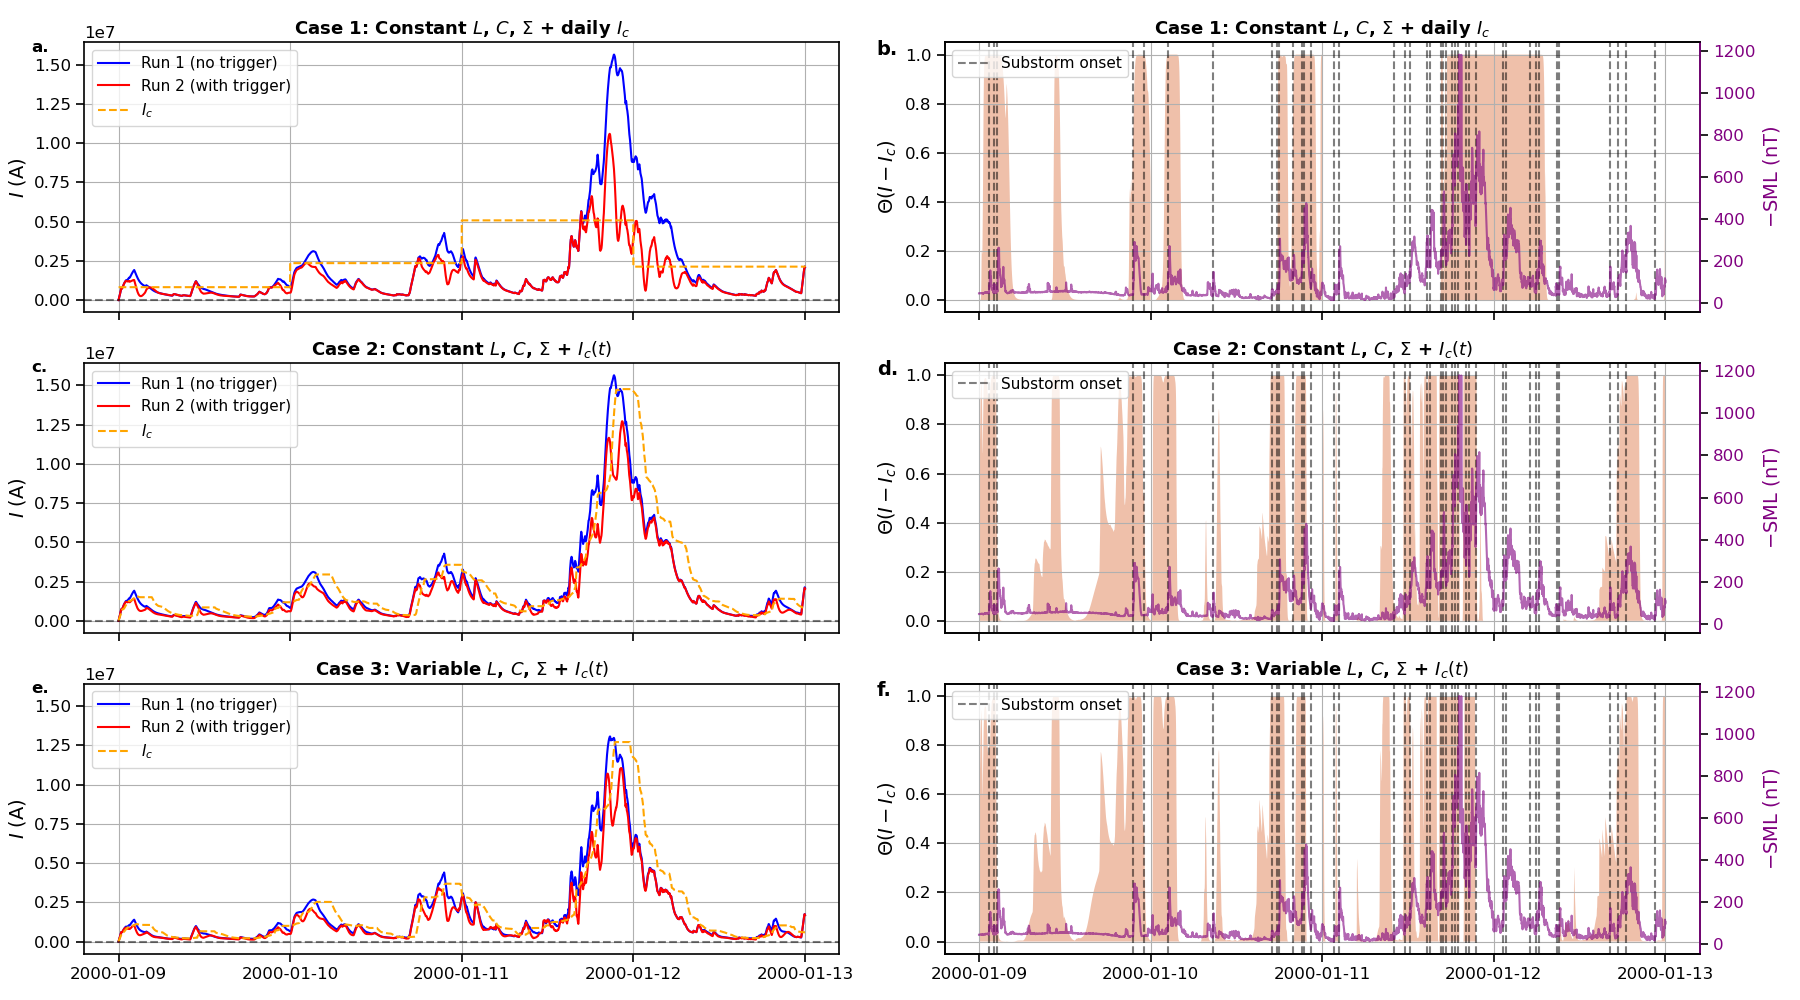

In [ ]:
import matplotlib.dates as mdates


fig, ax = plt.subplots(3, 2, figsize=(18, 10), sharex=True,
                       gridspec_kw={'height_ratios': [1, 1, 1]})

cases = [
    (out_no_trig_0, out_trig_0, Ic_0, theta_0,
     'Case 1: Constant $L$, $C$, $\Sigma$ + daily $I_c$'),
    (out_no_trig_1, out_trig_1, Ic_1, theta_1,
     'Case 2: Constant $L$, $C$, $\Sigma$ + $I_c(t)$'),
    (out_no_trig_2, out_trig_2, Ic_2, theta_2,
     'Case 3: Variable $L$, $C$, $\Sigma$ + $I_c(t)$'),
]

for i, (no_trig, trig, Ic, theta, title) in enumerate(cases):

    # --- left column: geotail current ---
    ax[i, 0].plot(no_trig.index, no_trig['I'],
                  c='blue', label='Run 1 (no trigger)')
    ax[i, 0].plot(trig.index, trig['I'],
                  c='red', label='Run 2 (with trigger)')
    ax[i, 0].plot(no_trig.index, Ic,
                  c='orange', ls='--', label='$I_c$')
    ax[i, 0].set_ylabel('$I$ (A)', fontsize=14)
    ax[i, 0].set_title(title, fontsize=13)
    ax[i, 0].legend(loc='upper left', fontsize=11)
    ax[i, 0].grid(True)
    ax[i, 0].text(-0.07, 1.01,
                  f'{chr(97 + 2*i)}.',
                  transform=ax[i, 0].transAxes,
                  fontsize=12, fontweight='bold', va='top')

    # --- right column: theta + SML ---
    ax[i, 1].fill_between(no_trig.index, 0, theta,
                          facecolor='#D8622C', alpha=0.4)
    ax[i, 1].set_ylabel('$\\Theta(I - I_c)$', fontsize=14)
    ax[i, 1].set_title(title, fontsize=13)
    ax[i, 1].grid(True)
    ax[i, 1].text(-0.09, 1.01,
                  f'{chr(97 + 2*i + 1)}.',
                  transform=ax[i, 1].transAxes,
                  fontsize=14, fontweight='bold', va='top')

    for t in substorms_all.index:
        ax[i, 1].axvline(
            t, c='k', alpha=0.5, ls='--',
            label='Substorm onset'
            if 'Substorm onset'
            not in ax[i, 1].get_legend_handles_labels()[1] else ''
        )
    ax[i, 1].legend(loc='upper left', fontsize=11)

    ax2 = ax[i, 1].twinx()
    ax2.plot(-SuperMag.SML.loc[start:stop],
             color='purple', alpha=0.6)
    ax2.set_ylabel('$-$SML (nT)', c='purple', fontsize=14)
    ax2.tick_params(axis='y', labelcolor='purple')
    ax2.spines['right'].set_color('purple')

# uniform y-limits on the left column
ymin = min(ax[i, 0].get_ylim()[0] for i in range(3))
ymax = max(ax[i, 0].get_ylim()[1] for i in range(3))
for i in range(3):
    ax[i, 0].set_ylim(ymin, ymax)
    if ymin < 0:
        ax[i, 0].axhline(0, color='k', alpha=0.5, ls='--')

# x-axis formatting
for i in range(3):
    for j in range(2):
        ax[i, j].xaxis.set_major_locator(mdates.DayLocator(interval=1))
        ax[i, j].xaxis.set_major_formatter(
            mdates.DateFormatter('%Y-%m-%d'))
# plt.setp(ax[2, 0].xaxis.get_majorticklabels(), rotation=30, ha='right')
# plt.setp(ax[2, 1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig(
    f"C:/Users/soumy/OneDrive/Documents/Plots/"
    f"windmi_combined_{start.strftime('%Y-%m-%d')}_"
    f"{stop.strftime('%Y-%m-%d')}.jpg",
    dpi=300, bbox_inches='tight'
)
plt.show()